This notebook is dedicated to EDA (exploratory data analysis). It is meant to find hidden relationships before we start handling the main problem and solution.

In [1]:
#Adding Imports and setup

import os, sys, json, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from dateutil import parser as dateparser
from sklearn.model_selection import train_test_split

In [2]:
# Make plots a bit nicer
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

In [3]:
#Create Paths
project_root = Path.cwd().resolve().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
data_dir = project_root / "data"

true_data_path = data_dir / "True.csv"
fake_data_path = data_dir / "Fake.csv"

true_data_path, fake_data_path, project_root


(PosixPath('/Users/karinahernandez/accenture-ai-studio-fall2025/data/True.csv'),
 PosixPath('/Users/karinahernandez/accenture-ai-studio-fall2025/data/Fake.csv'),
 PosixPath('/Users/karinahernandez/accenture-ai-studio-fall2025'))

In [26]:
#Load datasets
true_df = pd.read_csv(true_data_path)
fake_df = pd.read_csv(fake_data_path)

print("true shape:", true_df.shape)
print("fake shape:", fake_df.shape)

display(true_df.head(3))
display(fake_df.head(3))


true shape: (21417, 4)
fake shape: (23481, 4)


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"


Slightly more Fake articles than True ones.

In [35]:
#Adding labels and combining datasets
true_df = true_df.copy()
true_df["target"] = 1
true_df["source_tag"] = "true_csv"

fake_df = fake_df.copy()
fake_df["target"] = 0
fake_df["source_tag"] = "fake_csv"

df = pd.concat([true_df, fake_df], ignore_index=True)
print("combined shape:", df.shape)
df.sample(3, random_state=58)

combined shape: (44898, 6)


,title,text,subject,date,target,source_tag
3905,"With Obamacare vote, House Republicans free to...",WASHINGTON (Reuters) - The Republican-controll...,politicsNews,"May 5, 2017",1,true_csv
23776,The Vacationer-In-Chief Was Asked To Grade Hi...,Amateur president Donald Trump s first thirty ...,News,"February 28, 2017",0,fake_csv
11113,North Carolina's voter ID law goes on trial,"WINSTON-SALEM, N.C. (Reuters) - Minority voter...",politicsNews,"January 25, 2016",1,true_csv


Datasets are now combined into 1 huge data set with a new column known as "target" that refers to what is True or Fake.

In [36]:
# Missingness
missing = df.isna().mean().sort_values(ascending=False)
display(missing.head(20))


title         0.0
text          0.0
subject       0.0
date          0.0
target        0.0
source_tag    0.0
dtype: float64

No missing values found.

In [37]:
#Parsing dates to find potential patterns
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["dayofweek"] = df["date"].dt.dayofweek

In [38]:
df.head()

,title,text,subject,date,target,source_tag,year,month,dayofweek
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,2017-12-31,1,true_csv,2017.0,12.0,6.0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,2017-12-29,1,true_csv,2017.0,12.0,4.0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,2017-12-31,1,true_csv,2017.0,12.0,6.0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,2017-12-30,1,true_csv,2017.0,12.0,5.0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,2017-12-29,1,true_csv,2017.0,12.0,4.0


In [39]:
#Quick text features for EDA: title and text lengths and words
df["title_len"] = df["title"].astype(str).str.len()
df["text_len"]  = df["text"].astype(str).str.len()
df["title_words"] = df["title"].astype(str).str.split().str.len()
df["text_words"]  = df["text"].astype(str).str.split().str.len()


In [40]:
df.head()

,title,text,subject,date,target,source_tag,year,month,dayofweek,title_len,text_len,title_words,text_words
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,2017-12-31,1,true_csv,2017.0,12.0,6.0,64,4659,10,749
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,2017-12-29,1,true_csv,2017.0,12.0,4.0,64,4077,9,624
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,2017-12-31,1,true_csv,2017.0,12.0,6.0,60,2789,10,457
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,2017-12-30,1,true_csv,2017.0,12.0,5.0,59,2461,9,376
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,2017-12-29,1,true_csv,2017.0,12.0,4.0,69,5204,11,852


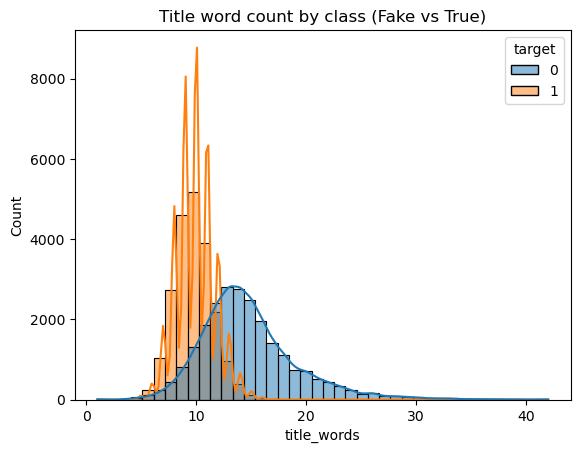

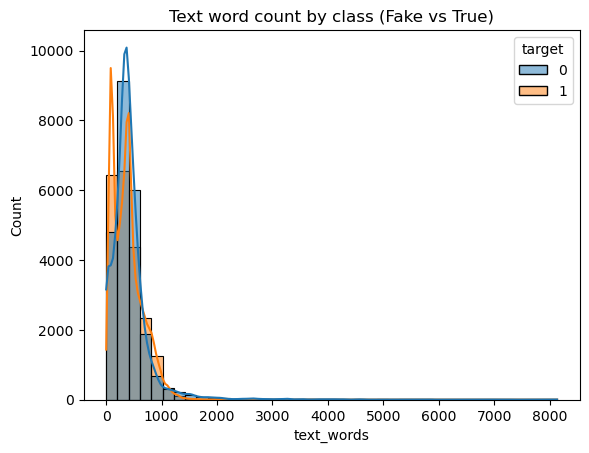

In [ ]:
#Simple visuals of connection between Target and title/text word counts
import seaborn as sns

sns.histplot(data=df, x="title_words", hue="target", bins=40, kde=True)
plt.title("Title word count by class (Fake vs True)")
plt.show()

sns.histplot(data=df, x="text_words", hue="target", bins=40, kde=True)
plt.title("Text word count by class (Fake vs True)")
plt.show()


In [ ]:
#Leakage & drift checks
print("Subject by class:")
display(df.groupby(["target","subject"]).size().unstack(fill_value=0))

# Correlation with label for numeric features
print("\nCorrelations with target:")
display(df[["target","title_len","text_len","title_words","text_words"]].corr(numeric_only=True)["target"].sort_values(ascending=False))


Subject by class:


subject,Government News,Middle-east,News,US_News,left-news,politics,politicsNews,worldnews
target,,,,,,,,
0,1570,778,9050,783,4459,6841,0,0
1,0,0,0,0,0,0,11272,10145



Correlations with target:


target         1.000000
text_len      -0.037747
text_words    -0.053405
title_words   -0.580489
title_len     -0.581159
Name: target, dtype: float64

Table suggests that we cannot go based on subject since it immediately detects fake or true news. We will drop this column since it is a major leak issue.

Correlations and graphs also show longer titles are more likely to be Fake. However, it is hard to tell much from text words.

In [45]:
#Drop Subject column
df = df.drop(columns=["subject"])

# Drop duplicates
df = df.drop_duplicates(subset=["text"]).dropna(subset=["title","text","target"])

# Combine text fields
df["all_text"] = (df["title"].astype(str) + " " + df["text"].astype(str)).str.strip()

#Meta data columns
meta_cols = ["title_words","text_words","title_len","text_len"]

In [46]:
df.head()

,title,text,date,target,source_tag,year,month,dayofweek,title_len,text_len,title_words,text_words,all_text
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,2017-12-31,1,true_csv,2017.0,12.0,6.0,64,4659,10,749,"As U.S. budget fight looms, Republicans flip t..."
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,2017-12-29,1,true_csv,2017.0,12.0,4.0,64,4077,9,624,U.S. military to accept transgender recruits o...
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,2017-12-31,1,true_csv,2017.0,12.0,6.0,60,2789,10,457,Senior U.S. Republican senator: 'Let Mr. Muell...
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,2017-12-30,1,true_csv,2017.0,12.0,5.0,59,2461,9,376,FBI Russia probe helped by Australian diplomat...
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,2017-12-29,1,true_csv,2017.0,12.0,4.0,69,5204,11,852,Trump wants Postal Service to charge 'much mor...


In [47]:
#Train test split
X = df[["all_text"] + meta_cols]
y = df["target"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_train.shape, X_test.shape

((30916, 5), (7730, 5))

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Text + numeric preprocessors
text_vec = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1,2),    # unigrams + bigrams
    max_features=100_000,
    min_df=2
)

preprocess = ColumnTransformer(
    transformers=[
        ("tfidf", text_vec, "all_text"),
        ("num",   StandardScaler(with_mean=False), meta_cols),
    ],
    remainder="drop",
    sparse_threshold=0.3,
)

clf = LogisticRegression(
    max_iter=1000,
    solver="liblinear"
)

pipe = Pipeline([
    ("prep", preprocess),
    ("clf",  clf),
])

pipe


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('tfidf',
                                                  TfidfVectorizer(max_features=100000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  stop_words='english'),
                                                  'all_text'),
                                                 ('num',
                                                  StandardScaler(with_mean=False),
                                                  ['title_words', 'text_words',
                                                   'title_len',
                                                   'text_len'])])),
                ('clf', LogisticRegression(max_iter=1000, solver='liblinear'))])

In [49]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred, digits=3))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)
cm


              precision    recall  f1-score   support

           0      0.996     0.970     0.983      3491
           1      0.976     0.997     0.986      4239

    accuracy                          0.985      7730
   macro avg      0.986     0.984     0.985      7730
weighted avg      0.985     0.985     0.985      7730

ROC-AUC: 0.9983046081694653


array([[3388,  103],
       [  14, 4225]])

The model is well predicting what is fake and true without the need of the subject column. We can see higher than 90% in precision for both.

In [ ]:
# Get feature names for tfidf part
tfidf = pipe.named_steps["prep"].named_transformers_["tfidf"]
tfidf_vocab = tfidf.get_feature_names_out()
n_tfidf = len(tfidf_vocab)

# Coefs come from the final LR over [tfidf | scaled meta]
coefs = pipe.named_steps["clf"].coef_.ravel()

tfidf_coefs = coefs[:n_tfidf]
top_true_idx  = np.argsort(tfidf_coefs)[-25:][::-1]   # highest positive → True(1)
top_fake_idx  = np.argsort(tfidf_coefs)[:25]          # most negative → Fake(0)

print("\nTop tokens predicting TRUE (1):")
for i in top_true_idx:
    print(f"{tfidf_vocab[i]:<25}  {tfidf_coefs[i]:.4f}")

print("\nTop tokens predicting FAKE (0):")
for i in top_fake_idx:
    print(f"{tfidf_vocab[i]:<25}  {tfidf_coefs[i]:.4f}")



Top tokens predicting TRUE (1):
said                       16.7731
reuters                    15.7007
washington reuters         6.8207
washington                 4.5064
president donald           4.3797
wednesday                  4.3659
tuesday                    3.9354
thursday                   3.7720
minister                   3.7470
republican                 3.6266
friday                     3.6167
reuters president          3.4789
monday                     3.3698
nov                        2.8672
edt                        2.6390
spokesman                  2.6292
told                       2.5656
democratic                 2.5013
china                      2.4765
presidential               2.4759
government                 2.4457
told reuters               2.4408
said statement             2.4302
moscow                     2.3660
tax                        2.3344

Top tokens predicting FAKE (0):
video                      -7.3573
image                      -6.0413
just        

Now we have a list of words that can help identify was is True or Fake.